# Shimadzu Ascii files to traces and integrals

what we're trying to do here is get the ascii files from shimadzu and transform them into hplc traces to get integrals of shit

In [3]:
import pandas as pd
import re

def extract_data_as_columns(filepath):
    """
    Extracts multiple PDA Multi Chromatogram blocks from a text file and returns a DataFrame.

    Each block is assumed to have the same r.time values (retention time) but different intensity
    measurements corresponding to a specific wavelength. The intensity column header will be set
    to the wavelength value (prefixed for clarity).

    The file is expected to have blocks like:

        [PDA Multi Chromatogram(Ch2)]
        # of Points       1751
        Interval(msec)    240
        Start Time(min)   0
        End Time(min)     7
        Intensity Units   mAU
        Intensity Multiplier  1
        Type  MultiChrom
        Wavelength(nm)    248
        Bandwidth(nm)     4
        R.Time (min)      Intensity
        0.00000   0
        0.00400   0
        ...

    Returns:
        pd.DataFrame: A DataFrame with a column 'r_time' for retention time and one column per block,
                      named using the wavelength value.
    """
    blocks = []

    with open(filepath, 'r') as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        line = lines[i].strip()
        # Identify the start of a block
        if line.startswith("[PDA Multi Chromatogram"):
            header = {}
            i += 1
            # Process header lines until reaching the data header or first data row
            while i < len(lines):
                cur_line = lines[i].strip()
                if not cur_line:
                    i += 1
                    continue
                # If we hit the column header or a numeric row, break out of header parsing.
                if cur_line.startswith("R.Time") or re.match(r"^\d", cur_line):
                    break
                parts = cur_line.split()
                if len(parts) >= 2:
                    key = " ".join(parts[:-1])
                    value = parts[-1]
                    header[key] = value
                i += 1

            # Retrieve wavelength and number of points from header
            wavelength = header.get("Wavelength(nm)", None)
            try:
                num_points = int(header.get("# of Points", 0))
            except ValueError:
                num_points = 0

            # If current line is the data column header, skip it.
            if i < len(lines) and "R.Time" in lines[i]:
                i += 1

            # Extract r.time and intensity values for the block.
            r_times = []
            intensities = []
            for _ in range(num_points):
                if i < len(lines):
                    parts = lines[i].strip().split()
                    if len(parts) >= 2:
                        try:
                            r_time = float(parts[0])
                            intensity = float(parts[1])
                            r_times.append(r_time)
                            intensities.append(intensity)
                        except ValueError:
                            pass
                    i += 1

            # Save the block data as a tuple: (wavelength, r_times, intensities)
            blocks.append((wavelength, r_times, intensities))
        else:
            i += 1

    # Build the final DataFrame using r.time from the first block.
    if not blocks:
        return pd.DataFrame()

    # Assume the r.time values are identical across blocks.
    df = pd.DataFrame({'r_time': blocks[0][1]})

    # Add an intensity column for each block, using the wavelength as the column header.
    for block in blocks:
        wl, r_times, intensities = block
        col_name = f"Intensity_{wl}" if wl is not None else "Intensity"
        df[col_name] = intensities

    return df


def extract_3d_data(filepath):
    """
    Extracts the PDA 3D data block from a text file and returns a DataFrame.

    The file is expected to have a block like:

        [PDA 3D]
        Interval(msec)          240
        Start Time(min)         0.000
        End Time(min)           7.000
        Start Wavelength(nm)    190
        End Wavelength(nm)      350
        # of Wavelength Axis Points  130
        # of Time Axis Points         1751
        R.Time (min)
                18895   19019   19143 ... 35072
        0.00000 0       0       0   ... 0
        19000   0       0       0   ... 0
        ...

    Here the first row after "R.Time (min)" gives the retention time values. Each subsequent row
    represents a wavelength, with its first value equal to the wavelength (multiplied by 100) and the
    remaining values being intensity measurements for each time point.

    Returns:
        pd.DataFrame: A DataFrame with index given by the retention times (converted to floats)
                      and columns labeled by wavelength in nm (obtained by dividing the first column by 100).
                      The DataFrame values are the intensity readings.
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()

    # Find the PDA 3D block
    i = 0
    while i < len(lines) and "[PDA 3D]" not in lines[i]:
        i += 1
    if i == len(lines):
        raise ValueError("No PDA 3D block found in the file.")

    # Advance past the [PDA 3D] line and read metadata
    i += 1
    metadata = {}
    while i < len(lines):
        line = lines[i].strip()
        # Stop when we hit the header that begins with "R.Time"
        if line.startswith("R.Time"):
            i += 1  # move to the line with the retention times
            break
        if line:
            # Expect key and value separated by whitespace; key can be multiple words.
            parts = line.split()
            if len(parts) >= 2:
                key = " ".join(parts[:-1])
                value = parts[-1]
                metadata[key] = value
        i += 1

    # Extract expected metadata items (if needed later)
    try:
        num_wavelengths = int(metadata.get("# of Wavelength Axis Points", 0))
        num_time_points = int(metadata.get("# of Time Axis Points", 0))
    except ValueError:
        raise ValueError("Could not parse number of axis points from metadata.")

    # Parse the retention times row.
    # The row might have an initial blank entry if the first column is reserved for wavelength.
    rt_line = lines[i].strip()
    rt_parts = rt_line.split()
    try:
        # Convert all parts to float; if there is an extra first element that is not numeric, skip it.
        wavelengths = [float(x)/100 for x in rt_parts if x.replace('.','',1).isdigit()]
    except Exception as e:
        raise ValueError("Error parsing retention times.") from e
    i += 1  # move to the first data row

    # Prepare lists to hold wavelengths and intensity data rows.
    retention_times = []
    intensity_rows = []

    # Read the next 'num_wavelengths' rows.
    for _ in range(num_time_points):
        if i >= len(lines):
            break
        parts = lines[i].strip().split()
        if not parts:
            i += 1
            continue
        # The first value is wavelength*100. Divide by 100 to get wavelength in nm.
        try:
            rt = float(parts[0])
        except ValueError:
            rt = None
        retention_times.append(rt)
        # The remaining parts are intensity values. Convert them to float.
        try:
            intensities = [float(x) for x in parts[1:]]
        except ValueError:
            intensities = []
        intensity_rows.append(intensities)
        i += 1

    # Check that we have the expected number of intensity points per row.
    if intensity_rows and len(intensity_rows[0]) != len(wavelengths):
        raise ValueError("Mismatch between number of time points and intensity values per wavelength.")

    # Create a DataFrame from the intensity data.
    # The intensity_rows list is of shape (num_wavelengths x num_time_points).
    # We want a DataFrame with index as retention times and columns as wavelengths.
    df_intensity = pd.DataFrame(intensity_rows, index=retention_times, columns=wavelengths)

    # It is often more convenient to have retention times as rows. So we transpose the DataFrame.
    df_intensity.index.name = "wavelength"
    # The column names are the wavelengths.
    df_intensity.columns.name = "r_time"

    return df_intensity

# test_file = "enzymatic_data/batch_1/raw_text_files/blank.txt"
# df_1 = extract_3d_data(test_file)
# test_file_2 = "enzymatic_data/batch_1/raw_text_files/run 1.txt"
# df_2 = extract_3d_data(test_file_2)
#

Function above works, now let's run trhough the given folder and save in the new folder

In [4]:
import os

source_path = "enzymatic_data/batch_1/raw_text_files"
dest_path = "enzymatic_data/batch_1/sample_traces"

os.makedirs(dest_path, exist_ok=True)

for file in os.listdir(source_path):
    if not file.endswith(".txt"):
        continue

    source_file = os.path.join(source_path, file)
    dest_file = os.path.join(dest_path, file.replace(".txt", ".csv"))

    df = extract_data_as_columns(source_file)
    df.to_csv(dest_file, index=False)
    print(f"Saved {dest_file}")

print("Done!")

Saved shimadzu_data/batch_1/sample_traces/clean 9.csv
Saved shimadzu_data/batch_1/sample_traces/clean 20.csv
Saved shimadzu_data/batch_1/sample_traces/clean 21.csv
Saved shimadzu_data/batch_1/sample_traces/clean 8.csv
Saved shimadzu_data/batch_1/sample_traces/clean 23.csv
Saved shimadzu_data/batch_1/sample_traces/clean 22.csv
Saved shimadzu_data/batch_1/sample_traces/clean 26.csv
Saved shimadzu_data/batch_1/sample_traces/clean 27.csv
Saved shimadzu_data/batch_1/sample_traces/blank_8.csv
Saved shimadzu_data/batch_1/sample_traces/clean 25.csv
Saved shimadzu_data/batch_1/sample_traces/clean 19.csv
Saved shimadzu_data/batch_1/sample_traces/clean 18.csv
Saved shimadzu_data/batch_1/sample_traces/clean 24.csv
Saved shimadzu_data/batch_1/sample_traces/Shutdown.csv
Saved shimadzu_data/batch_1/sample_traces/clean f.csv
Saved shimadzu_data/batch_1/sample_traces/clean 15.csv
Saved shimadzu_data/batch_1/sample_traces/clean 14.csv
Saved shimadzu_data/batch_1/sample_traces/clean 28.csv
Saved shimadzu

In [5]:
source_dir = "enzymatic_data/batch_1/raw_text_files"
dest_dir = "enzymatic_data/batch_1/samples_3d"

os.makedirs(dest_dir, exist_ok=True)

for file in os.listdir(source_dir):
    if not file.endswith(".txt"):
        continue

    print(f"Processing {file}")
    try:
        source_file = os.path.join(source_dir, file)
        dest_file = os.path.join(dest_dir, file.replace(".txt", ".csv"))

        df = extract_3d_data(source_file)
        df.to_csv(dest_file)
        print(f"Saved {dest_file}")
    except Exception as e:
        print(f"Error processing {file}: {e}")


Processing clean 9.txt
Saved shimadzu_data/batch_1/samples_3d/clean 9.csv
Processing clean 20.txt
Saved shimadzu_data/batch_1/samples_3d/clean 20.csv
Processing clean 21.txt
Saved shimadzu_data/batch_1/samples_3d/clean 21.csv
Processing clean 8.txt
Saved shimadzu_data/batch_1/samples_3d/clean 8.csv
Processing clean 23.txt
Saved shimadzu_data/batch_1/samples_3d/clean 23.csv
Processing clean 22.txt
Saved shimadzu_data/batch_1/samples_3d/clean 22.csv
Processing clean 26.txt
Saved shimadzu_data/batch_1/samples_3d/clean 26.csv
Processing clean 27.txt
Saved shimadzu_data/batch_1/samples_3d/clean 27.csv
Processing blank_8.txt
Saved shimadzu_data/batch_1/samples_3d/blank_8.csv
Processing clean 25.txt
Saved shimadzu_data/batch_1/samples_3d/clean 25.csv
Processing clean 19.txt
Saved shimadzu_data/batch_1/samples_3d/clean 19.csv
Processing clean 18.txt
Saved shimadzu_data/batch_1/samples_3d/clean 18.csv
Processing clean 24.txt
Saved shimadzu_data/batch_1/samples_3d/clean 24.csv
Processing Shutdow

# Calibration Curves:
ok now we take the CSVs of SM, TMB, Product 1 and Product 2 and 1) we plot them, 2) we select the best W-len 3) we find integration limits 4) we integrate
and 5 make a calibration curve (with linear model)

In [6]:
sm_traces = {file: float(''.join(filter(str.isdigit, file))) for file in os.listdir(dest_path) if "SM" in file}
tmb_traces = {file: float(''.join(filter(str.isdigit, file))) for file in os.listdir(dest_path) if "TMB" in file}
product1_traces = {file: float(''.join(filter(str.isdigit, file))) for file in os.listdir(dest_path) if "Product" in file}
product2_traces= {file: float(''.join(filter(str.isdigit, file.replace('Product2', '')))) for file in os.listdir(dest_path) if "Product2" in file}
run_traces = {file: f"Run{int(''.join(filter(str.isdigit, file))):02d}" for file in os.listdir(dest_path) if "run" in file}


In [7]:
# now we plot them
import matplotlib.pyplot as plt
#turn off the grid and background of matplotlub
plt.rcParams.update(plt.rcParamsDefault)


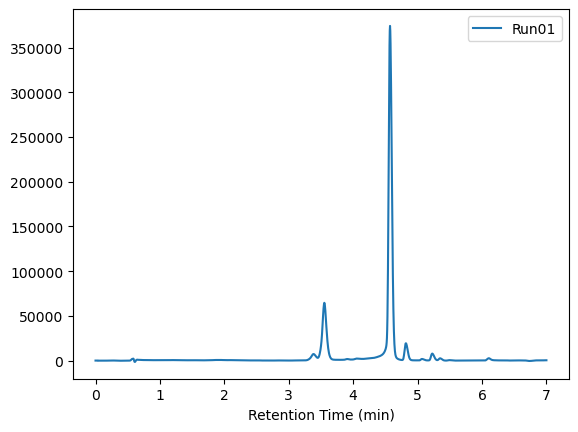

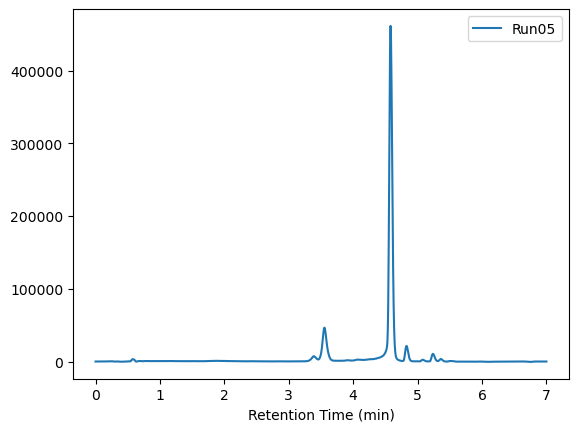

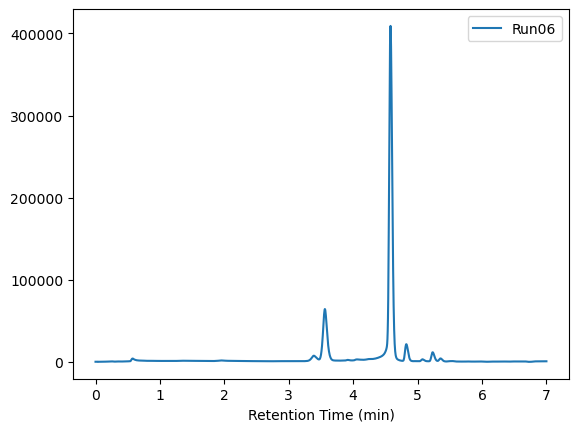

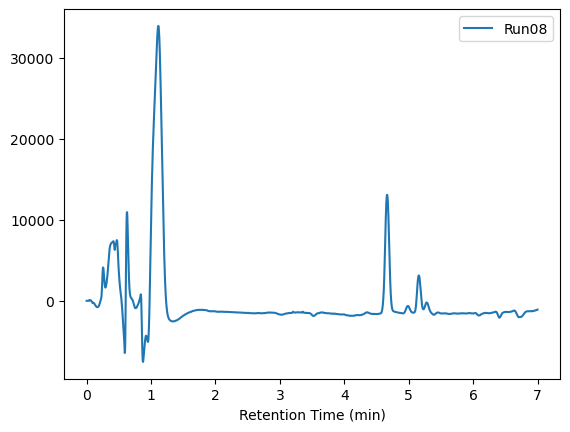

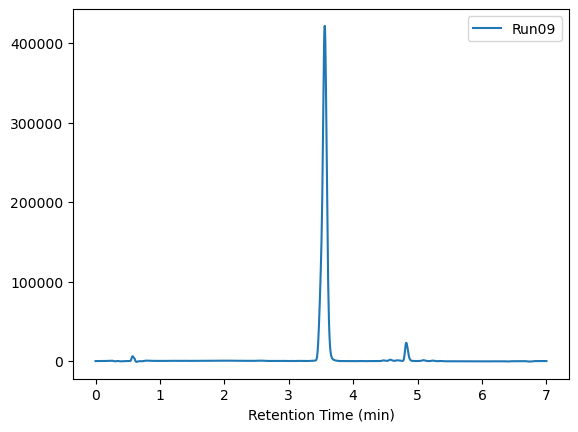

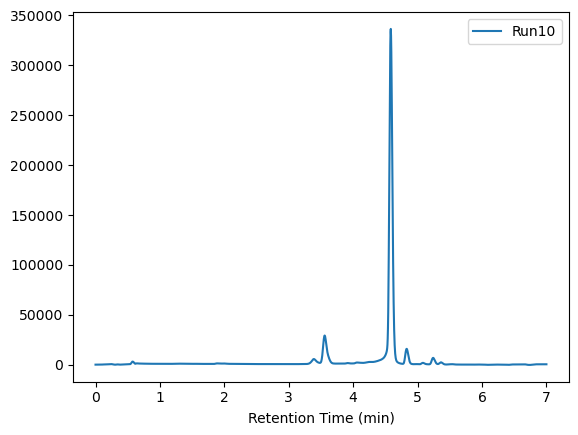

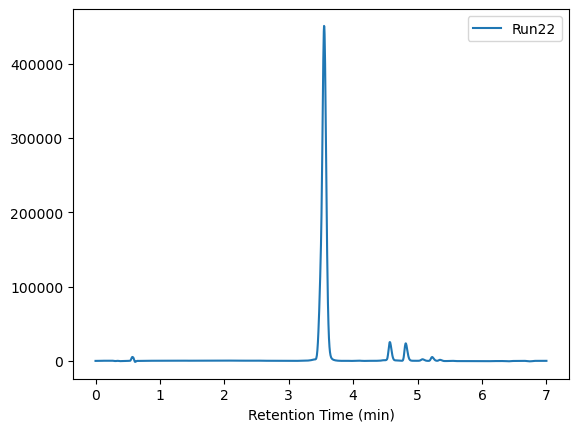

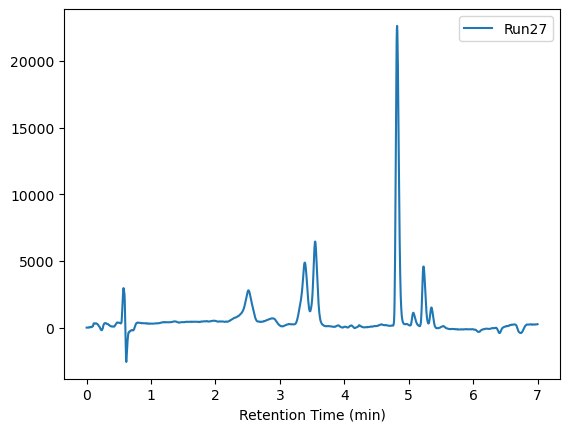

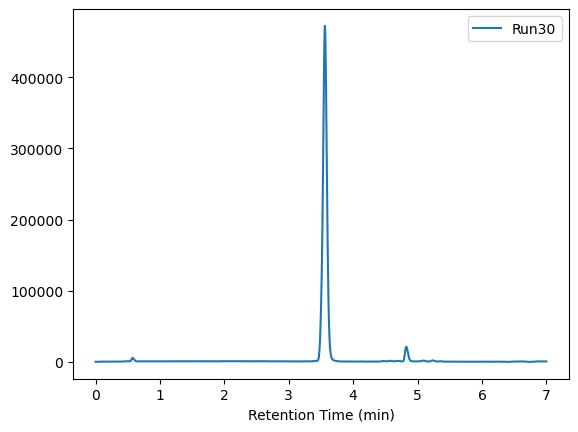

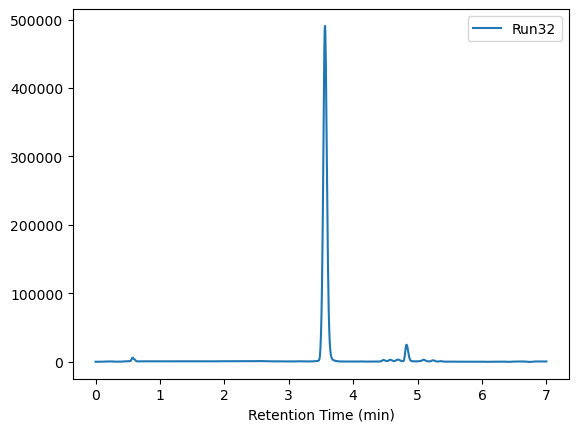

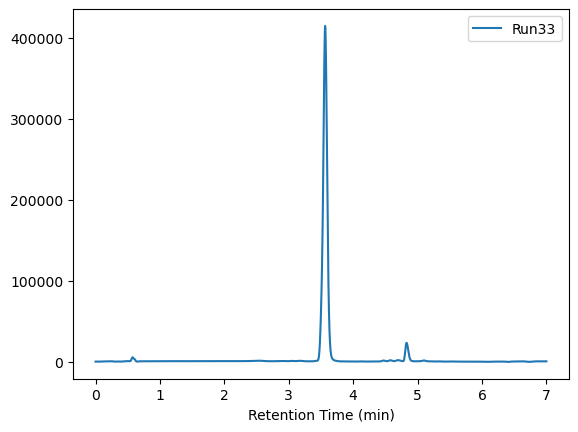

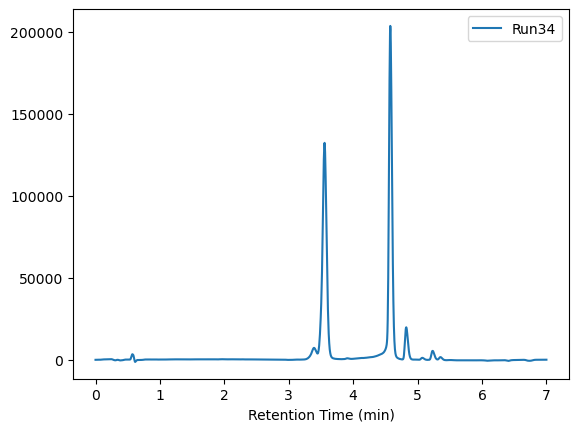

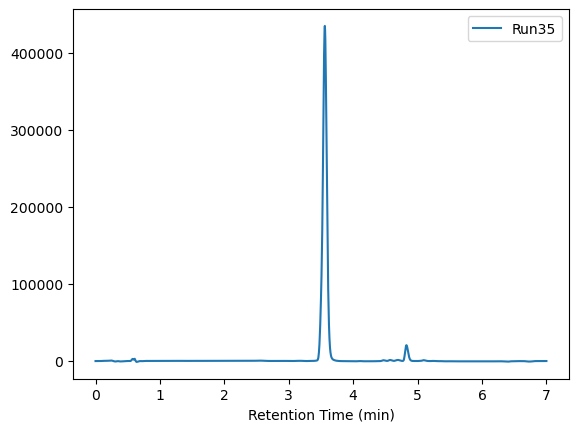

In [8]:
blank = pd.read_csv(os.path.join(dest_path, "Blank.csv"))
#
# for file, _ in sm_traces.items():
#     df = pd.read_csv(os.path.join(dest_path, file))
#     plt.plot(df['r_time'], df['Intensity_254']-blank['Intensity_254'], label=file)
# plt.legend()
# plt.show()
#
# for file, _ in tmb_traces.items():
#     df = pd.read_csv(os.path.join(dest_path, file))
#     plt.plot(df['r_time'], df['Intensity_254']-blank['Intensity_254'], label=file)
# plt.legend()
# plt.show()
#
# for file, _ in tmb_traces.items():
#     df3d = pd.read_csv(os.path.join(dest_dir, file))
#     plt.imshow(df3d, aspect='auto', cmap='viridis')
#     plt.title(file)
#     plt.plot()
# #
# for file, _ in product1_traces.items():
#     df = pd.read_csv(os.path.join(dest_path, file))
#     plt.plot(df['r_time'], df['Intensity_254']-blank['Intensity_254'], label=file)
# plt.legend()
# plt.show()

# sort run traces by value:
run_traces = {k: v for k, v in sorted(run_traces.items(), key=lambda item: item[1])}

for file, name in run_traces.items():
    df = pd.read_csv(os.path.join(dest_path, file))
    plt.plot(df['r_time'], df['Intensity_254']-blank['Intensity_254'], label=name)
    plt.legend()
    plt.xlabel('Retention Time (min)')
    if name in ["Run09", 'Run08', 'Run27']:
        plt.savefig(f"enzymatic_data/{name}.png")
    plt.show()



In [9]:
#make calibration curves
results_path = "enzymatic_data/all/250-320"
sm_files = {file: float(''.join(filter(str.isdigit, file))) for file in os.listdir(results_path) if "SM" in file}
tmb_files = {file: float(''.join(filter(str.isdigit, file))) for file in os.listdir(results_path) if "TMB" in file}
product1_files = {file: float(''.join(filter(str.isdigit, file))) for file in os.listdir(results_path) if "Product" in file and not "Product2" in file}
product2_files = {file: float(''.join(filter(str.isdigit, file.replace('Product2', '')))) for file in os.listdir(results_path) if "Product2" in file}
run_files = {
    file: f"Run{int(''.join(filter(str.isdigit, file))):02d}"
    for file in os.listdir(results_path) if "run" in file.lower()
}
results_path_sideproduct = "enzymatic_data/all/200-210"
run_files_sideproduct = {
    file: f"Run{int(''.join(filter(str.isdigit, file))):02d}"
    for file in os.listdir(results_path_sideproduct) if "run" in file.lower()
}
sideprooduct_files = {file: float(''.join(filter(str.isdigit, file))) for file in os.listdir(results_path_sideproduct) if "byproduct" in file}
sm_files, tmb_files, product1_files, product2_files, run_files, run_files_sideproduct, sideprooduct_files

({'SM 1mM_result.csv': 1.0,
  'SM 7mM_result.csv': 7.0,
  'SM 10mM_result.csv': 10.0,
  'SM 3mM_result.csv': 3.0},
 {'TMB 7mM_result.csv': 7.0,
  'TMB 10mM_result.csv': 10.0,
  'TMB 3mM_result.csv': 3.0},
 {'Product 3mM_result.csv': 3.0,
  'Product 10mM_result.csv': 10.0,
  'Product 1mM_result.csv': 1.0,
  'Product 7mM_result.csv': 7.0},
 {'Product2 1mM_result.csv': 1.0,
  'Product2 7mM_result.csv': 7.0,
  'Product2 3mM_result.csv': 3.0},
 {'run 53_result.csv': 'Run53',
  'run 64_result.csv': 'Run64',
  'run 75_result.csv': 'Run75',
  'run 42_result.csv': 'Run42',
  'run 93_result.csv': 'Run93',
  'run 70_result.csv': 'Run70',
  'run 34_result.csv': 'Run34',
  'run 6_result.csv': 'Run06',
  'run 82_result.csv': 'Run82',
  'run 1_result.csv': 'Run01',
  'run 85_result.csv': 'Run85',
  'run 33_result.csv': 'Run33',
  'run 22_result.csv': 'Run22',
  'run 40_result.csv': 'Run40',
  'run 9_result.csv': 'Run09',
  'run 10_result.csv': 'Run10',
  'run 27_result.csv': 'Run27',
  'run 72_result

In [10]:
#peak matching function:
import numpy as np
def get_common_peak(dfs):
    """
    Given a list of DataFrames (each with columns:
      'peak_rt', 'integral', 'peak_height', 'peak_width', 'diastereomer_A', 'diastereomer_B')
    this function finds one peak (one row from each DataFrame) with the closest retention times (peak_rt)
    and returns a new DataFrame (with one row) representing the aggregated peak. Aggregation here is done
    by taking the mean of each column across the matched peaks.

    The algorithm works as follows:

    1. For each peak in the first DataFrame, treat it as a candidate.
    2. For each other DataFrame, find the row with a peak_rt closest to the candidate's peak_rt.
    3. Compute the maximum absolute difference between the candidate's peak_rt and the matched peak_rt's.
    4. Choose the candidate with the smallest maximum difference.
    5. Aggregate the values from these matched rows (using mean) to return a single row.

    Returns:
        pd.DataFrame: A DataFrame with one row containing the aggregated peak data.
    """
    if not dfs:
        raise ValueError("List of DataFrames is empty.")

    # Use the first DataFrame as the candidate source.
    candidate_df = dfs[0]
    best_max_diff = np.inf
    best_matches = None  # This will store a list of matched rows (as Series) from each df.

    # Loop over each candidate row in the first DataFrame.
    for idx, candidate_row in candidate_df.iterrows():
        candidate_rt = candidate_row['peak_rt']
        current_matches = [candidate_row]
        max_diff = 0

        # For each subsequent DataFrame, find the row with the closest peak_rt.
        for other_df in dfs[1:]:
            # Compute absolute differences.
            diffs = other_df['peak_rt'].sub(candidate_rt).abs()
            best_index = diffs.idxmin()
            best_row = other_df.loc[best_index]
            current_matches.append(best_row)
            current_diff = abs(best_row['peak_rt'] - candidate_rt)
            max_diff = max(max_diff, current_diff)

        # Choose the candidate with the smallest maximum difference.
        if max_diff < best_max_diff:
            best_max_diff = max_diff
            best_matches = current_matches

    if best_matches is None:
        raise ValueError("No matching peaks found across all DataFrames.")

    # Aggregate the matched peaks: here we take the mean for each column.
    aggregated = {}
    # Assume all dataframes have the same columns.
    for col in candidate_df.columns:
        # Compute the mean of this column over the matched rows.
        values = [match[col] for match in best_matches]
        aggregated[col] = np.mean(values)

    # Return as a one-row DataFrame.
    return pd.DataFrame([aggregated])

def get_common_peak_from_dict(dfs_dict):
    """
    Given a dict of DataFrames (each having columns:
      'peak_rt', 'integral', ...),
    this function finds, across all DataFrames, a set of peaks whose retention times are as close as possible.
    It returns a single-row DataFrame with columns for each key of the input dict:
      <key>_peak_rt, <key>_integral

    The algorithm works as follows:
      1. Use the DataFrame from the first key as candidate source.
      2. For each candidate in that DataFrame, find the peak in each other DataFrame that is closest in peak_rt.
      3. Compute the maximum absolute difference in peak_rt between the candidate and the matches.
      4. Choose the candidate with the smallest maximum difference.
      5. Return a DataFrame with columns named "<key>_peak_rt" and "<key>_integral" for each input key.
    """
    if not dfs_dict:
        raise ValueError("The input dictionary is empty.")

    # Sort the keys so that we have a reproducible order.
    keys = list(dfs_dict.keys())
    candidate_df = dfs_dict[keys[0]]

    best_max_diff = np.inf
    best_matches = {}  # will map each key to the matched row (a Series)

    # Loop over each candidate row in the first DataFrame.
    for idx, candidate_row in candidate_df.iterrows():
        candidate_rt = candidate_row['peak_rt']
        current_matches = {keys[0]: candidate_row}
        max_diff = 0

        # For each other DataFrame, find the row with the closest peak_rt.
        for key in keys[1:]:
            df = dfs_dict[key]
            # Compute absolute difference between candidate_rt and each peak_rt in this DataFrame.
            diffs = df['peak_rt'].sub(candidate_rt).abs()
            best_index = diffs.idxmin()
            best_row = df.loc[best_index]
            current_matches[key] = best_row
            current_diff = abs(best_row['peak_rt'] - candidate_rt)
            max_diff = max(max_diff, current_diff)

        # Update best match if this candidate has a smaller max difference.
        if max_diff < best_max_diff:
            best_max_diff = max_diff
            best_matches = current_matches.copy()

    if not best_matches:
        raise ValueError("No matching peaks found across the DataFrames.")

    # Build the results DataFrame with one row per sample.
    results = []
    for key in keys:
        row = best_matches[key]
        # Convert the integral by dividing by 100 (per your output expectation)
        converted_integral = round(row['integral'] / 100)
        results.append({
            "sample": key,
            "peak_rt": row['peak_rt'],
            "peak_integral": converted_integral
        })

    return pd.DataFrame(results)

def get_peaks_near_rt(dfs_dict, target_rt, tolerance, fill_zero = False):
    """
    Given a dict of DataFrames (each having columns 'peak_rt', 'integral', etc.),
    this function finds all peaks in each DataFrame whose retention times (peak_rt)
    are within a specified tolerance of a manually input target retention time.

    It returns a DataFrame with three columns:
      - sample: the key from the input dictionary,
      - peak_rt: the retention time of the matching peak,
      - peak_integral: the integral converted by dividing by 100 and rounded.

    Parameters:
      dfs_dict (dict): Dictionary with keys as sample names and values as DataFrames.
      target_rt (float): The target retention time.
      tolerance (float): The tolerance around target_rt within which peaks are considered a match.

    Returns:
      pd.DataFrame: A DataFrame listing all matching peaks per sample.
    """
    if not dfs_dict:
        raise ValueError("The input dictionary is empty.")

    results = []

    # Loop over each sample and filter for rows that are within tolerance of the target_rt.
    for sample, df in dfs_dict.items():
        # Compute absolute difference between each peak_rt and the target.
        matches = df[abs(df['peak_rt'] - target_rt) <= tolerance]
        # For each match, record the sample, peak_rt, and converted peak_integral.
        for _, row in matches.iterrows():
            results.append({
                "sample": sample,
                "peak_rt": row['peak_rt'],
                "peak_integral": round(row['integral'] / 100)
            })
    # if no peaks were matching put a 0
    if fill_zero:
        for sample in dfs_dict.keys():
            if sample not in [result['sample'] for result in results]:
                results.append({
                    "sample": sample,
                    "peak_rt": target_rt,
                    "peak_integral": 0
                })

    return pd.DataFrame(results)

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def fit_and_plot_from_df(df, title_name = '', fit_intercept = True):
    """
    Given a DataFrame with columns 'sample' (independent variable as float) and 'peak_integral'
    (dependent variable), this function fits a linear regression through the points (forcing a zero
    intercept), calculates the R² value, and plots_data1 the data along with the fit.

    Parameters:
        df (pd.DataFrame): DataFrame containing at least the columns 'sample' and 'peak_integral'.

    Returns:
        slope (float): Fitted slope of the regression.
        r2 (float): R² value of the fit.
    """
    # Extract x (sample) and y (peak_integral) from the DataFrame.
    x = np.array(df['sample']).reshape(-1, 1)
    y = np.array(df['peak_integral'])

    # Fit linear regression with zero intercept.
    model = LinearRegression(fit_intercept=fit_intercept)
    model.fit(x, y)

    slope = model.coef_[0]
    y_pred = model.predict(x)

    # Calculate R² value.
    r2 = r2_score(y, y_pred)

    # Plot data and the fitted line.
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, color='blue', label='Buchwald Mapping Points')
    plt.plot(x, y_pred, color='red',linestyle = '--',
             label=f'Fit: y = {slope:.2f}x\n$R^2$ = {r2:.3f}')
    plt.xlabel('Sample')
    plt.ylabel('Peak Integral')
    plt.title(f'Calibration curve of {title_name}')
    plt.legend()
    plt.show()

    return slope, r2, model

# Calibration curves:

## TMB

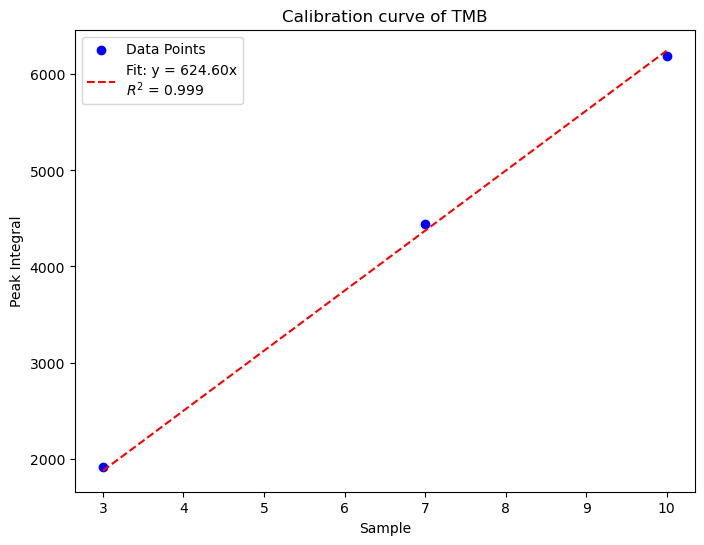

In [12]:
dfs_tmb = {value: pd.read_csv(os.path.join(results_path, key)) for key, value in tmb_files.items()}
tmb_rt = 4.83
common_peak_tmb = get_peaks_near_rt(dfs_tmb, target_rt=tmb_rt, tolerance=0.01)
common_peak_tmb.sort_values(by='sample', inplace=True)
tmb_model = fit_and_plot_from_df(common_peak_tmb, title_name='TMB', fit_intercept=False)


   sample  peak_rt  peak_integral
0     1.0    4.588          12194
3     3.0    4.584          38319
1     7.0    4.588          91615
2    10.0    4.588         133127


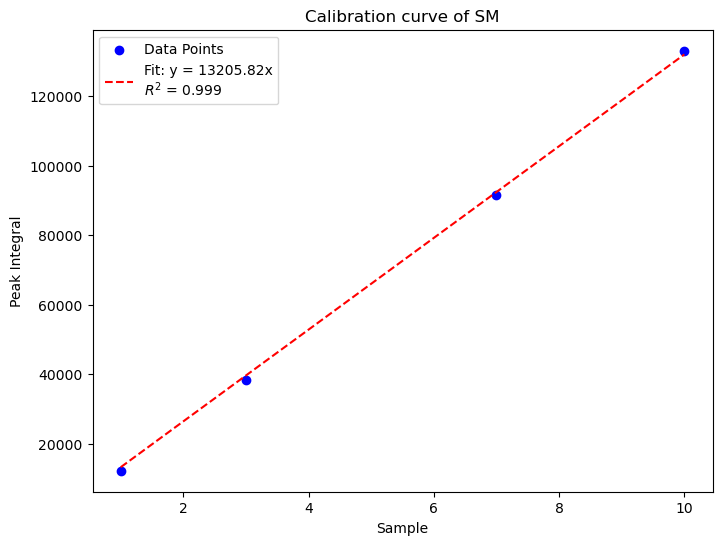

In [13]:
dfs_sm = {value: pd.read_csv(os.path.join(results_path, key)) for key, value in sm_files.items()}
rt_sm = 4.588
common_peak_sm = get_peaks_near_rt(dfs_sm, target_rt=rt_sm, tolerance=0.01)
common_peak_sm.sort_values(by='sample', inplace=True)
print(common_peak_sm)

sm_model = fit_and_plot_from_df(common_peak_sm, title_name='SM', fit_intercept=False)

   sample  peak_rt  peak_integral
0     3.0    3.568          21052
1    10.0    3.576          67934
2     1.0    3.572           6903
3     7.0    3.576          48365
0     1.0    3.572           7378
1     7.0    3.572          51258
2     3.0    3.576          22154


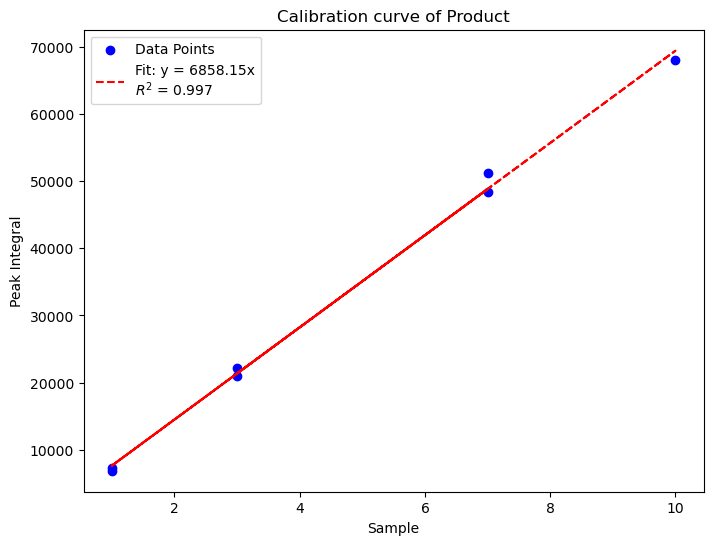

In [14]:
dfs_product1 = {value: pd.read_csv(os.path.join(results_path, key)) for key, value in product1_files.items()}
dfs_product2 = {value: pd.read_csv(os.path.join(results_path, key)) for key, value in product2_files.items()}
rt_product = 3.57
common_peak_product_1 = get_peaks_near_rt(dfs_product1, target_rt=rt_product, tolerance=0.01)
common_peak_product_2 = get_peaks_near_rt(dfs_product2, target_rt=rt_product, tolerance=0.01)
common_peak_product = pd.concat([common_peak_product_1, common_peak_product_2])
common_peak_product.sort_values(by='sample', inplace=False)
print(common_peak_product)

product_model = fit_and_plot_from_df(common_peak_product, title_name='Product', fit_intercept=True)

   sample  peak_rt  peak_integral
2     3.0    3.432          94430
1     7.0    3.424         175246
0    10.0    3.440         211332


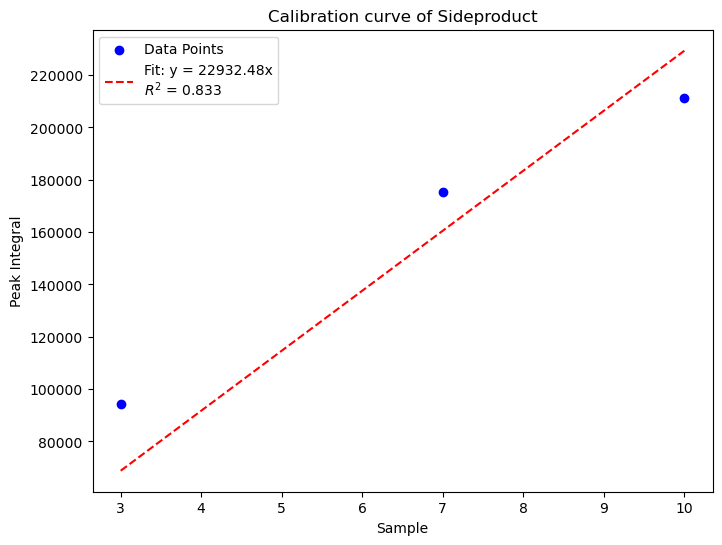

In [15]:
# sideproduct cal curve

dfs_sideproduct = {value: pd.read_csv(os.path.join(results_path_sideproduct, key)) for key, value in sideprooduct_files.items()}
rt_sideproduct = 3.39
common_peak_sideproduct = get_peaks_near_rt(dfs_sideproduct, target_rt=rt_sideproduct, tolerance=0.1)
common_peak_sideproduct.sort_values(by='sample', inplace=True)
print(common_peak_sideproduct)

sideproduct_model = fit_and_plot_from_df(common_peak_sideproduct, title_name='Sideproduct', fit_intercept=False)

linearity looks good, now let's find the product, sm and tmb in the runs:



<Axes: title={'center': 'Sideproduct in runs 2'}, xlabel='sample', ylabel='peak_integral'>

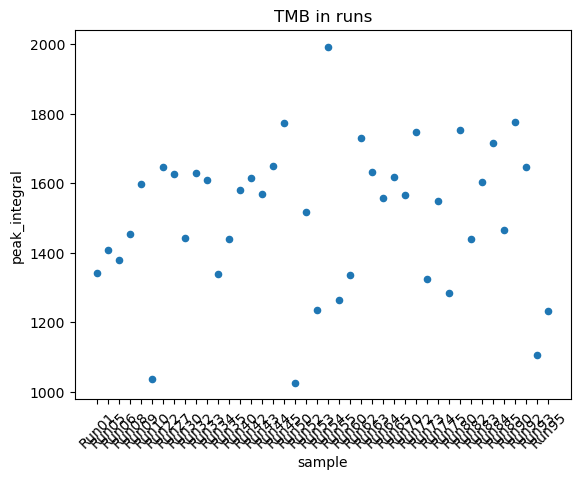

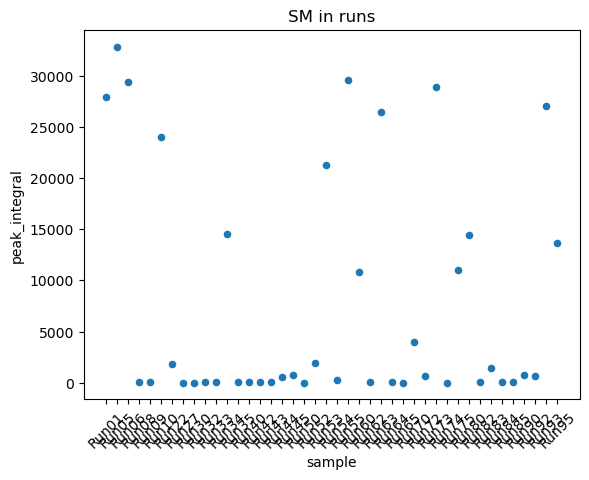

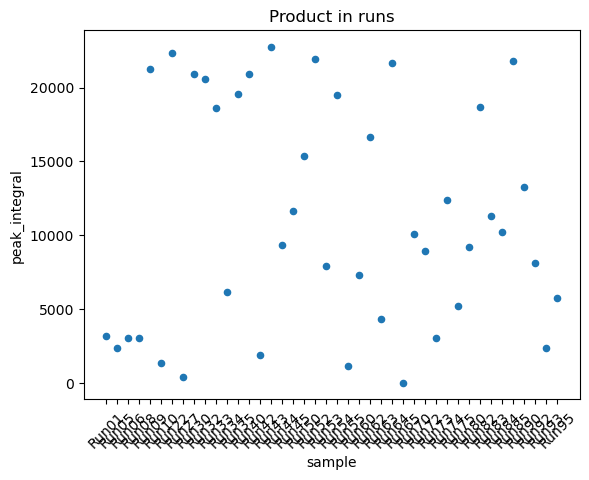

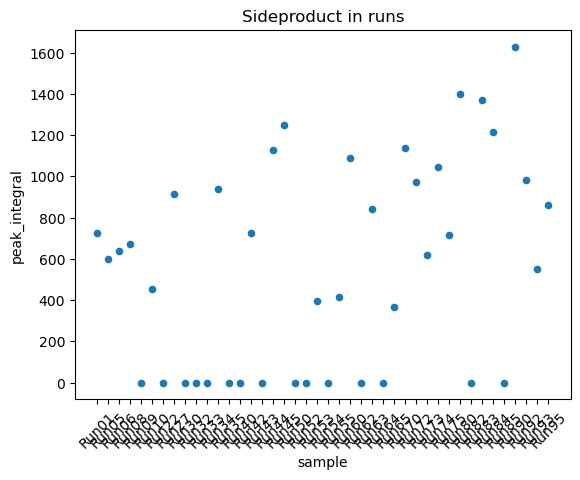

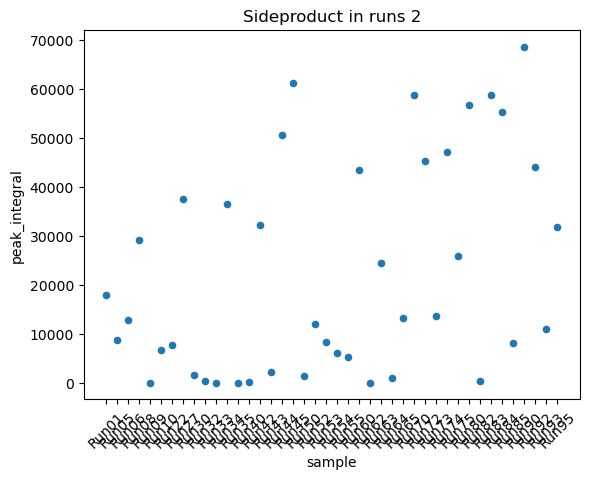

In [16]:
run_dfs = {value: pd.read_csv(os.path.join(results_path, key)) for key, value in run_files.items()}

tmb_in_runs = get_peaks_near_rt(run_dfs, target_rt=tmb_rt, tolerance=0.1, fill_zero=True)
sm_in_runs = get_peaks_near_rt(run_dfs, target_rt=rt_sm, tolerance=0.05, fill_zero=True)
product_in_runs = get_peaks_near_rt(run_dfs, target_rt=rt_product, tolerance=0.03, fill_zero=True)
sideproduct_in_runs = get_peaks_near_rt(run_dfs, target_rt=3.39, tolerance=0.1, fill_zero=True)

sideproduct_run_dfs = {value: pd.read_csv(os.path.join(results_path_sideproduct, key)) for key, value in run_files_sideproduct.items()}
sideproduct_in_runs_2 = get_peaks_near_rt(sideproduct_run_dfs, target_rt=3.39, tolerance=0.1, fill_zero=True)


# and now plot:
tmb_in_runs.sort_values(by='sample', inplace=True)
sm_in_runs.sort_values(by='sample', inplace=True)
product_in_runs.sort_values(by='sample', inplace=True)
sideproduct_in_runs.sort_values(by='sample', inplace=True)
sideproduct_in_runs_2.sort_values(by='sample', inplace=True)

tmb_in_runs.plot(x='sample', y='peak_integral', kind='scatter', title='TMB in runs', rot = 45)
sm_in_runs.plot(x = 'sample', y = 'peak_integral', kind = 'scatter', title = 'SM in runs',rot = 45)
product_in_runs.plot(x = 'sample', y = 'peak_integral', kind = 'scatter', title = 'Product in runs',rot = 45)
sideproduct_in_runs.plot(x = 'sample', y = 'peak_integral', kind = 'scatter', title = 'Sideproduct in runs',rot = 45)
sideproduct_in_runs_2.plot(x = 'sample', y = 'peak_integral', kind = 'scatter', title = 'Sideproduct in runs 2',rot = 45)

#stacked bar plot of sm product and sideproduct


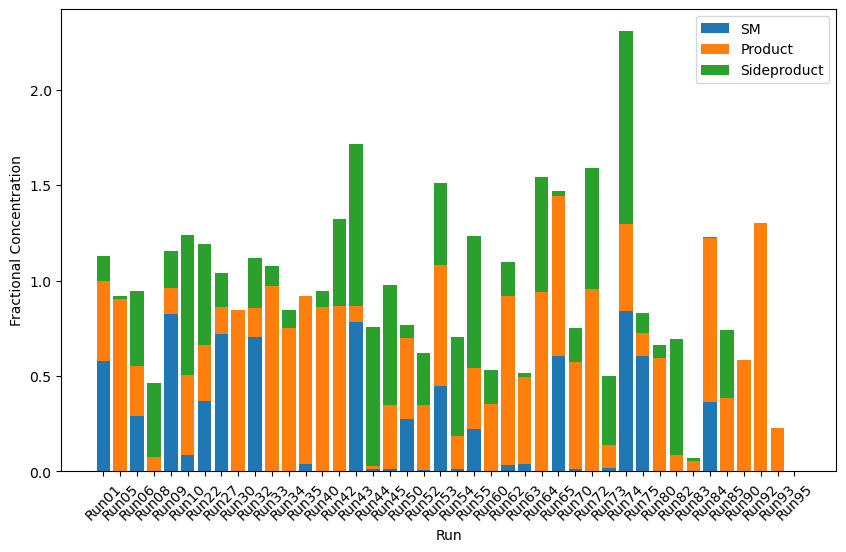

In [17]:
# make a stacked bar plot of the product, sm and sideproduct each normalised against the maximum of that type:
ratio_sm_tmb = sm_model[0]/tmb_model[0]
ratio_product_tmb = product_model[0]/tmb_model[0]
ratio_sideproduct_tmb = sideproduct_model[0]/tmb_model[0]

factor = 1/1.4

normal_tmb = tmb_in_runs['peak_integral'] / tmb_in_runs['peak_integral'].max() * factor
normal_sm = sm_in_runs['peak_integral'] / tmb_in_runs['peak_integral'] * 1/ratio_sm_tmb * factor
normal_product = product_in_runs['peak_integral'] / tmb_in_runs['peak_integral'] * 1/ratio_product_tmb * factor
normal_sideproduct = sideproduct_in_runs_2['peak_integral'] / tmb_in_runs['peak_integral'] * 1/ratio_sideproduct_tmb * factor

# Convert lists to numpy arrays for elementwise operations.
normal_sm = np.array(normal_sm)
normal_product = np.array(normal_product)
normal_sideproduct = np.array(normal_sideproduct)

# Assume that the x-values (samples) are the same for all.
# For instance, use one of them (or create a separate list/array).
x = sm_in_runs['sample']

plt.figure(figsize=(10, 6))
plt.bar(x, normal_sm, label='SM')
plt.bar(x, normal_product, bottom=normal_sm, label='Product')
plt.bar(x, normal_sideproduct, bottom=normal_sm + normal_product, label='Sideproduct')
plt.xticks(rotation=45)

plt.xlabel('Run')
plt.ylabel('Fractional Concentration')
plt.legend()
plt.savefig('enzymatic_data/stacked_bar_plot.png')
plt.show()


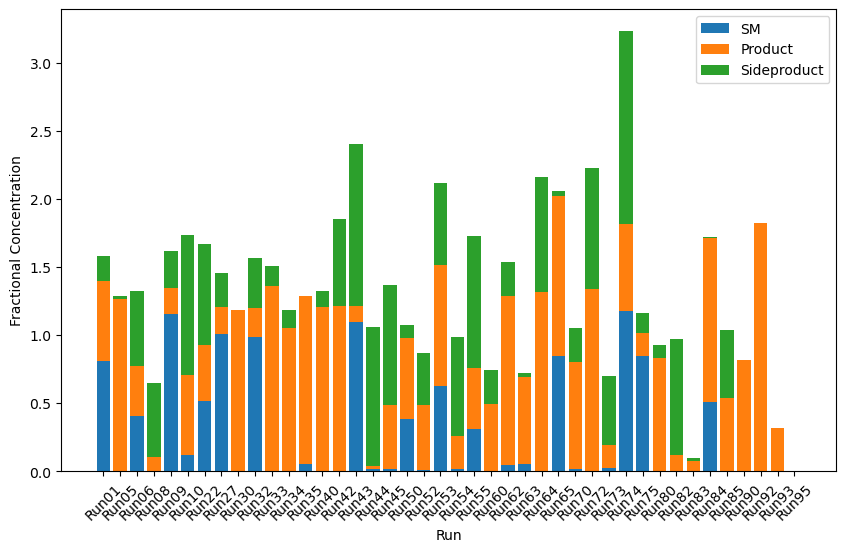

In [18]:
# make a stacked bar plot of the product, sm and sideproduct each normalised against the maximum of that type:
ratio_sm = sm_model[0]
ratio_product = product_model[0]
ratio_sideproduct = sideproduct_model[0]
ratio_tmb = tmb_model[0]

factor = 1 / 1.4

expected_sm_conc = 5
yield_tmb = (tmb_in_runs['peak_integral']/ratio_tmb)
yield_sm = (sm_in_runs['peak_integral']/ratio_sm)/yield_tmb
yield_product = (product_in_runs['peak_integral']/ratio_product)/yield_tmb
yield_sideproduct = (sideproduct_in_runs_2['peak_integral']/ratio_sideproduct)/yield_tmb



# Convert lists to numpy arrays for elementwise operations
yield_sm = np.array(yield_sm)
yield_product = np.array(yield_product)
yield_sideproduct = np.array(yield_sideproduct)

# Assume that the x-values (samples) are the same for all.
# For instance, use one of them (or create a separate list/array).
x = sm_in_runs['sample'].values

plt.figure(figsize=(10, 6))
plt.bar(x, yield_sm, label='SM')
plt.bar(x, yield_product, bottom=yield_sm, label='Product')
plt.bar(x, yield_sideproduct, bottom=yield_sm+yield_product, label='Sideproduct')
plt.xticks(rotation=45)

plt.xlabel('Run')
plt.ylabel('Fractional Concentration')
plt.legend()
plt.savefig('enzymatic_data/stacked_bar_plot.png')
plt.show()


   sample  peak_rt_sm  peak_integral_sm  peak_rt_product  \
0   Run01       4.572             27941            3.552   
1   Run05       4.580             32870            3.552   
2   Run06       4.580             29373            3.560   
3   Run08       4.584                50            3.556   
4   Run09       4.576                66            3.560   
5   Run10       4.584             24039            3.556   
6   Run22       4.568              1811            3.548   
7   Run27       4.588                 0            3.548   
8   Run30       4.588                 0            3.560   
9   Run32       4.576                43            3.564   
10  Run33       4.576                22            3.564   
11  Run34       4.576             14581            3.556   
12  Run35       4.576                24            3.560   
13  Run40       4.572                22            3.548   
14  Run42       4.572                71            3.552   
15  Run43       4.576                47 

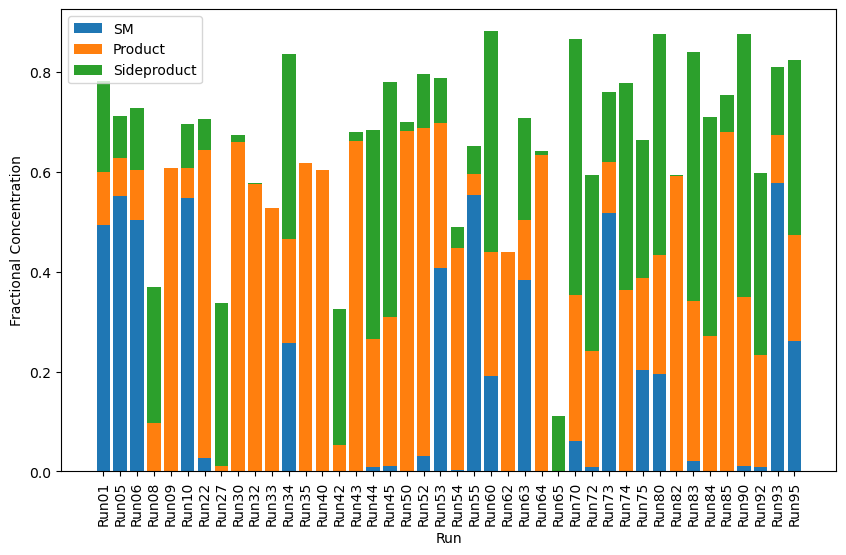

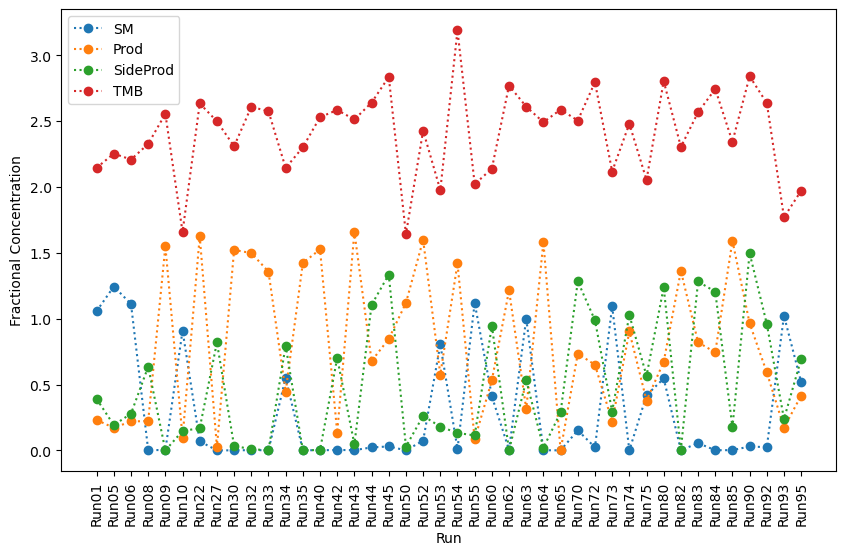

           sm_mm  product_mm  sideproduct_mm     tmb_mm
count  42.000000   42.000000       42.000000  42.000000
mean    0.293332    0.807211        0.491080   2.408489
std     0.428323    0.559582        0.474990   0.334203
min     0.000000    0.000000        0.000000   1.642648
25%     0.001145    0.251817        0.063027   2.162580
50%     0.023456    0.706969        0.284019   2.496395
75%     0.538673    1.405827        0.914238   2.610866
max     1.244527    1.659995        1.497636   3.190836


In [30]:
# generate a df with the integrals: merge on sample, change the names of the columns and print
integrals =  pd.merge(sm_in_runs, product_in_runs, on = 'sample', suffixes = ('_sm', '_product'))
integrals = pd.merge(integrals, sideproduct_in_runs_2, on = 'sample')
integrals = pd.merge(integrals, tmb_in_runs, on = 'sample', suffixes = ('', '_tmb'))
integrals.rename(columns = {'peak_integral': 'integral_sideproduct', 'peak_integral_tmb': 'integral_tmb'}, inplace = True)
print(integrals)


integrals['sm_mm'] = integrals['peak_integral_sm']/sm_model[0]/2
integrals['product_mm'] = integrals['peak_integral_product']/product_model[0]/2
integrals['sideproduct_mm'] = integrals['integral_sideproduct']/sideproduct_model[0]/2
integrals['tmb_mm'] = integrals['integral_tmb']/tmb_model[0]
integrals.loc[integrals['sample'] == 'Run27', 'tmb_mm'] = 2.5


integrals['sm_tmb'] = integrals['sm_mm']/integrals['tmb_mm']
integrals['product_tmb'] = integrals['product_mm']/integrals['tmb_mm']
integrals['sideproduct_tmb'] = integrals['sideproduct_mm']/integrals['tmb_mm']

integrals['sample_minimal'] = integrals['sample'].replace('Run', '')
integrals.to_csv('enzymatic_data/integrals_final.csv', index = False)

plt.figure(figsize=(10, 6))
plt.bar(integrals['sample_minimal'], integrals['sm_tmb'], label='SM')
plt.bar(integrals['sample_minimal'], integrals['product_tmb'], bottom=integrals['sm_tmb'], label='Product')
plt.bar(integrals['sample_minimal'], integrals['sideproduct_tmb'], bottom=integrals['sm_tmb']+integrals['product_tmb'], label='Sideproduct')
plt.xticks(rotation=90)

plt.xlabel('Run')
plt.ylabel('Fractional Concentration')
plt.legend()
# plt.savefig('enzymatic_data/stacked_bar_plot.png')
plt.show()

# plot the scatter version of the previous plot:
plt.figure(figsize=(10, 6))
# plt.plot(integrals['sample'], integrals['sm_tmb'], label='SM', linestyle=':', marker='o')
plt.plot(integrals['sample'], integrals['sm_mm'], label='SM', linestyle=':', marker='o')
plt.plot(integrals['sample'], integrals['product_mm'], label='Prod', linestyle=':', marker='o')
plt.plot(integrals['sample'], integrals['sideproduct_mm'], label='SideProd', linestyle=':', marker='o')
plt.plot(integrals['sample'], integrals['tmb_mm'], label='TMB', linestyle=':', marker='o')

plt.xticks(rotation=90)

plt.xlabel('Run')
plt.ylabel('Fractional Concentration')
plt.legend()
# plt.savefig('enzymatic_data/scatter_bar_plot.png')
plt.show()
print(integrals[['sm_mm', 'product_mm', 'sideproduct_mm', 'tmb_mm']].describe())

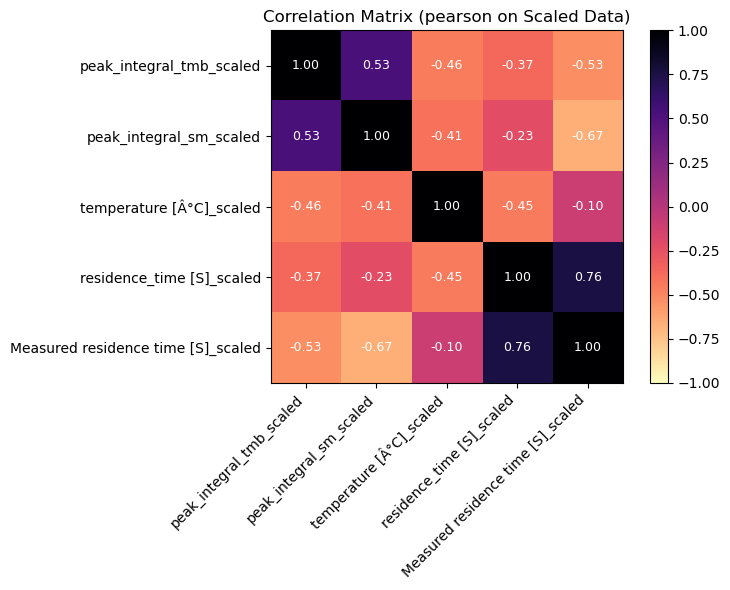

Linear Model (Scaled Data) for TMB Peak Integral:
  R² = 0.631
  Coefficients: [-0.74675884 -0.71054183]
  Intercept: 1.201

Linear Model (Scaled Data) for SM Peak Integral:
  R² = 0.390
  Coefficients: [-0.5687658  -0.47438497]
  Intercept: 0.991



/Users/es/miniforge3/envs/Opti_plotting_env_2/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


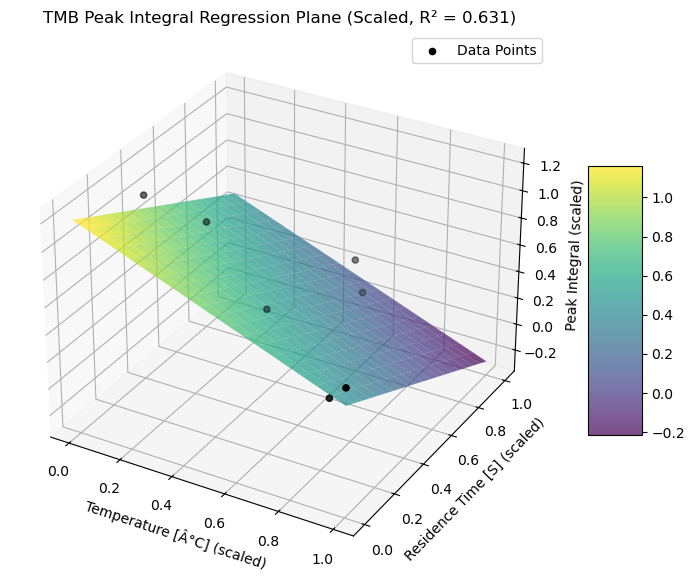

/Users/es/miniforge3/envs/Opti_plotting_env_2/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


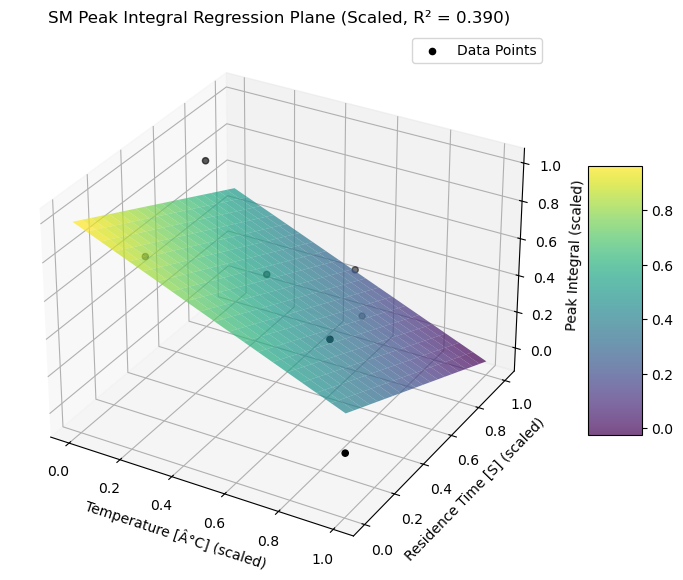

In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

check_files = {
    file: f"check{int(''.join(filter(str.isdigit, file))):02d}"
    for file in os.listdir(results_path) if "check" in file.lower()
}

check_df = {value: pd.read_csv(os.path.join(results_path, key)) for key, value in check_files.items()}
tmb_in_check = get_peaks_near_rt(check_df, target_rt=4.83, tolerance=0.1, fill_zero=True)

sm_in_check = get_peaks_near_rt(check_df, target_rt=4.58, tolerance=0.05, fill_zero=True)

integrals_in_check = pd.merge(tmb_in_check,sm_in_check, on = 'sample',  suffixes=('_tmb', '_sm'))
integrals_in_check.sort_values('sample', inplace = True)
integrals_in_check['conc_rt_sm'] = integrals_in_check['peak_integral_sm']/sm_model[0]
integrals_in_check['conc_rt_tmb'] = integrals_in_check['peak_integral_tmb']/tmb_model[0]






check_conditions = pd.read_csv('enzymatic_data/enz_reduction_control_SM.csv', index_col=0)
check_conditions['run'] = check_conditions['run'].apply(lambda x: f'check{x:02d}')
check_conditions = check_conditions[check_conditions['Failed'] == False]

# --- Buchwald Mapping Merging and Preprocessing ---

# Merge integrals and conditions assuming that the common identifier is sample/run.
merged_df = pd.merge(integrals_in_check, check_conditions, left_on="sample", right_on="run")

# Calculate the percent difference between set and measured residence times:
merged_df["rt_percent_diff"] = (np.abs(merged_df["Measured residence time [S]"] - merged_df["residence_time [S]"]) /
                                merged_df["residence_time [S]"]) * 100

# Specify the columns to scale:
cols_to_scale = ["peak_integral_tmb", "peak_integral_sm", "temperature [Â°C]",
                 "residence_time [S]", "Measured residence time [S]"]

# Scale the data between 0 and 1.
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(merged_df[cols_to_scale])
scaled_df = pd.DataFrame(scaled_values, columns=[col + "_scaled" for col in cols_to_scale])

# Concat the scaled data with the merged DataFrame.
merged_scaled = pd.concat([merged_df.reset_index(drop=True), scaled_df], axis=1)

# --- Correlation Plot on Scaled Buchwald Mapping ---

# Compute a Spearman correlation matrix for the scaled columns.
cols_for_corr = [col + "_scaled" for col in cols_to_scale]
corr_matrix = merged_scaled[cols_for_corr].corr(method='pearson')
plt.figure(figsize=(8, 6))
# Set vmin and vmax to 0 and 1 respectively, so the colorbar remains fixed.
im = plt.imshow(corr_matrix, cmap='magma_r', interpolation='nearest', vmin = -1, vmax = 1)
plt.colorbar(im)
plt.xticks(ticks=np.arange(len(corr_matrix.columns)), labels=corr_matrix.columns, rotation=45, ha='right')
plt.yticks(ticks=np.arange(len(corr_matrix.index)), labels=corr_matrix.index)

# Annotate with correlation coefficients:
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="w", fontsize=9)
plt.title("Correlation Matrix (pearson on Scaled Buchwald Mapping)")
plt.tight_layout()
plt.show()

# --- Linear Regression on Scaled Buchwald Mapping ---

# Use the scaled temperature and residence time as predictors:
X_scaled = merged_scaled[["temperature [Â°C]_scaled", "residence_time [S]_scaled"]]

# Use the scaled integrals as responses:
y_tmb_scaled = merged_scaled["peak_integral_tmb_scaled"]
y_sm_scaled = merged_scaled["peak_integral_sm_scaled"]

# Build linear regression models for the scaled data:
model_tmb_scaled = LinearRegression().fit(X_scaled, y_tmb_scaled)
model_sm_scaled = LinearRegression().fit(X_scaled, y_sm_scaled)

r2_tmb_scaled = model_tmb_scaled.score(X_scaled, y_tmb_scaled)
r2_sm_scaled = model_sm_scaled.score(X_scaled, y_sm_scaled)

# Retrieve coefficients and intercepts:
coef_tmb = model_tmb_scaled.coef_
intercept_tmb = model_tmb_scaled.intercept_
coef_sm = model_sm_scaled.coef_
intercept_sm = model_sm_scaled.intercept_

print("Linear Model (Scaled Buchwald Mapping) for TMB Peak Integral:")
print(f"  R² = {r2_tmb_scaled:.3f}")
print(f"  Coefficients: {coef_tmb}")
print(f"  Intercept: {intercept_tmb:.3f}\n")

print("Linear Model (Scaled Buchwald Mapping) for SM Peak Integral:")
print(f"  R² = {r2_sm_scaled:.3f}")
print(f"  Coefficients: {coef_sm}")
print(f"  Intercept: {intercept_sm:.3f}\n")

# --- 3D Regression Plotting on Scaled Buchwald Mapping ---

def plot_3d_regression(X, y, model, title, xlabel="Temperature [Â°C] (scaled)",
                         ylabel="Residence Time [S] (scaled)", zlabel="Peak Integral (scaled)"):
    """
    Creates a 3D scatter plot of the given data with the regression plane overlay.
    """
    # Create a meshgrid based on the range of the scaled predictors.
    x_range = np.linspace(X.iloc[:, 0].min(), X.iloc[:, 0].max(), 20)
    y_range = np.linspace(X.iloc[:, 1].min(), X.iloc[:, 1].max(), 20)
    xx, yy = np.meshgrid(x_range, y_range)

    # Predict across the grid.
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    zz = model.predict(grid).reshape(xx.shape)

    # Plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot actual data points.
    ax.scatter(X.iloc[:, 0], X.iloc[:, 1], y, c='black', marker='o', label='Buchwald Mapping Points')

    # Plot the regression plane.
    plane = ax.plot_surface(xx, yy, zz, cmap='viridis', alpha=0.7)
    fig.colorbar(plane, ax=ax, shrink=0.5, aspect=5)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)
    ax.set_title(title)
    plt.legend()
    plt.show()

# Plot 3D regression for TMB:
plot_3d_regression(X_scaled, y_tmb_scaled, model_tmb_scaled,
                   title=f"TMB Peak Integral Regression Plane (Scaled, R² = {r2_tmb_scaled:.3f})")

# Plot 3D regression for SM:
plot_3d_regression(X_scaled, y_sm_scaled, model_sm_scaled,
                   title=f"SM Peak Integral Regression Plane (Scaled, R² = {r2_sm_scaled:.3f})")

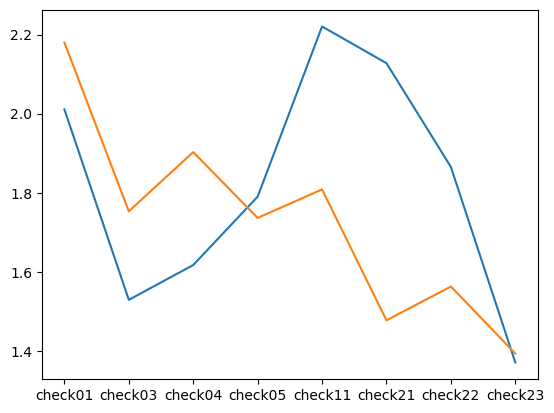

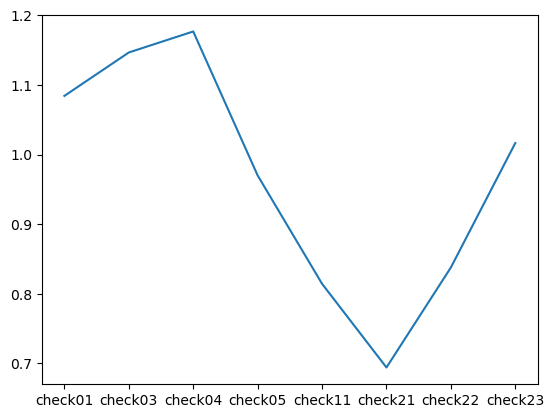

In [24]:
plt.plot(integrals_in_check['sample'], integrals_in_check['conc_rt_tmb'])
plt.plot(integrals_in_check['sample'], integrals_in_check['conc_rt_sm'])

plt.show()

plt.plot(integrals_in_check['sample'], integrals_in_check['conc_rt_sm']/integrals_in_check['conc_rt_tmb'])
plt.show()